In [22]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [23]:
df = pd.read_csv(r"C:\Users\bless\OneDrive\Desktop\banking-app-reveiws\data\mobile_banking_reviews_with_sentiment_themes.csv")

In [24]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bank                986 non-null    object 
 1   review              986 non-null    object 
 2   rating              986 non-null    int64  
 3   date                986 non-null    object 
 4   source              986 non-null    object 
 5   processed_review    972 non-null    object 
 6   sentiment_textblob  986 non-null    object 
 7   sentiment_vader     986 non-null    object 
 8   polarity            986 non-null    float64
 9   themes              986 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 77.2+ KB
None
                          bank  \
0  Commercial Bank of Ethiopia   
1  Commercial Bank of Ethiopia   
2  Commercial Bank of Ethiopia   
3  Commercial Bank of Ethiopia   
4  Commercial Bank of Ethiopia   

                                  

In [25]:
print("Unique banks:", df['bank'].unique())
print("Sample themes:", df['themes'].dropna().unique()[:10])

Unique banks: ['Commercial Bank of Ethiopia' 'Dashen Bank' 'Bank of Abyssinia']
Sample themes: ["['Transaction Performance', 'Customer Support']"
 "['User Interface & Experience']" "['Other']"
 "['User Interface & Experience', 'Customer Support']"
 "['Transaction Performance', 'User Interface & Experience']"
 "['Account Access Issues', 'Transaction Performance', 'User Interface & Experience', 'Feature Requests']"
 "['Customer Support']"
 "['User Interface & Experience', 'Feature Requests']"
 "['Transaction Performance']"
 "['Account Access Issues', 'User Interface & Experience']"]


In [26]:
def get_theme_counts(df, sentiment_col='sentiment_textblob', sentiment_type='positive'):
    themes = df[df[sentiment_col] == sentiment_type]['themes'].dropna().str.split(',')
    all_themes = [theme.strip().lower() for sublist in themes for theme in sublist]
    return Counter(all_themes).most_common(10)

banks = df['bank'].unique()

for bank in banks:
    print(f"\n🏦 {bank}")
    bank_df = df[df['bank'] == bank]

    print("🔼 Top Positive Drivers:")
    print(get_theme_counts(bank_df, sentiment_type='positive'))

    print("🔽 Top Negative Pain Points:")
    print(get_theme_counts(bank_df, sentiment_type='negative'))



🏦 Commercial Bank of Ethiopia
🔼 Top Positive Drivers:
[("['user interface & experience']", 84), ("['other']", 68), ("'user interface & experience']", 9), ("['transaction performance'", 8), ("'feature requests']", 7), ("['account access issues'", 6), ("['user interface & experience'", 5), ("['customer support']", 5), ("'customer support']", 3), ("'user interface & experience'", 3)]
🔽 Top Negative Pain Points:
[("['user interface & experience']", 10), ("['other']", 5), ("['transaction performance']", 3), ("'feature requests']", 2), ("['account access issues'", 1), ("'user interface & experience'", 1), ("'customer support'", 1), ("['customer support'", 1), ("['customer support']", 1)]

🏦 Dashen Bank
🔼 Top Positive Drivers:
[("['user interface & experience']", 121), ("['other']", 55), ("'feature requests']", 40), ("['user interface & experience'", 29), ("['transaction performance'", 26), ("'user interface & experience']", 15), ("'user interface & experience'", 15), ("'customer support']",

In [27]:
print(df.groupby('bank')['rating'].mean())

print(df.groupby(['bank', 'sentiment_textblob']).size().unstack(fill_value=0))


bank
Bank of Abyssinia              2.733129
Commercial Bank of Ethiopia    4.060703
Dashen Bank                    4.360231
Name: rating, dtype: float64
sentiment_textblob           negative  neutral  positive
bank                                                    
Bank of Abyssinia                  69      132       125
Commercial Bank of Ethiopia        21      112       180
Dashen Bank                        25       68       254


c:\Users\bless\OneDrive\Desktop\banking-app-reveiws\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


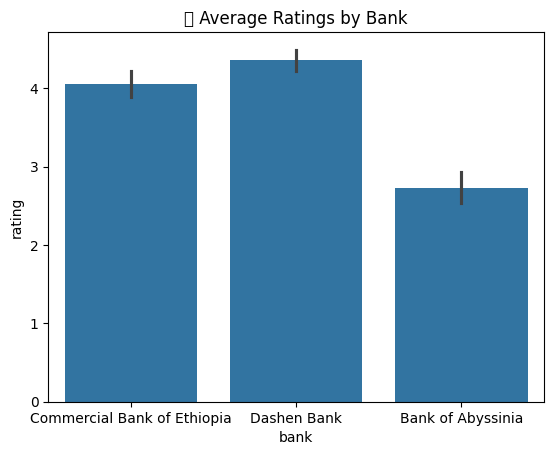

In [28]:
sns.barplot(data=df, x='bank', y='rating')
plt.title('📊 Average Ratings by Bank')
plt.show()

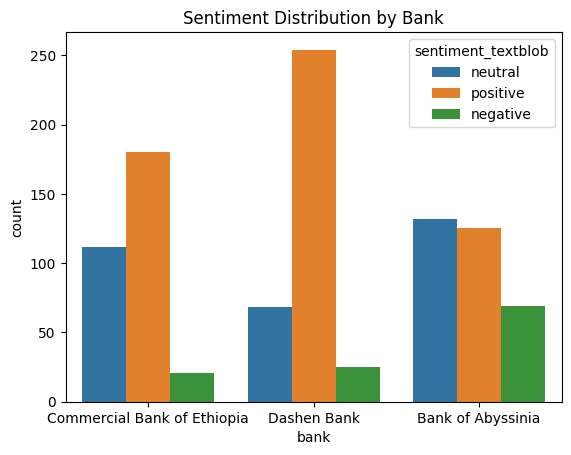

In [29]:
sns.countplot(data=df, x='bank', hue='sentiment_textblob')
plt.title('Sentiment Distribution by Bank')
plt.show()

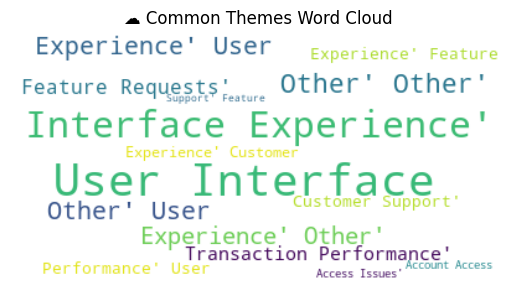

In [30]:
all_themes = ','.join(df['themes'].dropna().values)
wordcloud = WordCloud(background_color='white').generate(all_themes)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("☁️ Common Themes Word Cloud")
plt.show()